# PKLot Fast Optimized Notebook — Fixed Output Shape

This version fixes the EfficientNetV2 / ConvNeXt output shape error by flattening model outputs with `.view(-1)`.

## PKLot FAST OPTIMIZED VERSION - FIXED MODEL OUTPUT SHAPE

In [1]:
# ============================================================
# PKLot FAST OPTIMIZED VERSION - FIXED MODEL OUTPUT SHAPE
# Main fix: it does NOT crop all 497,856 boxes.
# It first samples annotations, then only crops the selected samples.

## FAST MODE: this is enough to finish quickly and show all required outputs.

In [2]:
# ============================================================
import os, json, time, random, shutil, warnings, subprocess, sys
from pathlib import Path
warnings.filterwarnings("ignore")

def install_if_missing(import_name, pip_name=None):
    try:
        __import__(import_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

install_if_missing("timm")
install_if_missing("cv2", "opencv-python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix, brier_score_loss, roc_curve, precision_recall_curve
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATA_ROOT = Path("/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset")
WORK_DIR = Path("/kaggle/working")
CROP_DIR = WORK_DIR / "pklot_fast_crops"
RESULTS_DIR = WORK_DIR / "pklot_results"
MODEL_DIR = WORK_DIR / "pklot_models"
for d in [CROP_DIR, RESULTS_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# FAST MODE: this is enough to finish quickly and show all required outputs.
# For final better run, use 1500 or 3000.
MAX_PER_CLASS_PER_SPLIT = 500

EPOCHS_CUSTOM = 2
EPOCHS_TRANSFER = 2

CATEGORY_TO_LABEL = {1: 0, 2: 1}
LABEL_TO_NAME = {0: "empty", 1: "occupied"}

Device: cuda


## 1. Build sampled annotation index FIRST

In [3]:
# ============================================================
# 1. Build sampled annotation index FIRST

## IMPORTANT: sample BEFORE crop

In [4]:
# ============================================================
def find_image(split_dir, file_name):
    candidates = [
        split_dir / file_name,
        split_dir / Path(file_name).name,
        split_dir / "images" / file_name,
        split_dir / "images" / Path(file_name).name,
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def load_sampled_annotations(split):
    split_dir = DATA_ROOT / split
    coco_path = split_dir / "_annotations.coco.json"
    with open(coco_path, "r") as f:
        coco = json.load(f)

    images = {img["id"]: img for img in coco["images"]}
    rows = []

    print(f"\nReading annotations for {split}")
    print("Images:", len(coco["images"]), "Annotations:", len(coco["annotations"]))

    for ann_idx, ann in enumerate(coco["annotations"]):
        cat = ann["category_id"]
        if cat not in CATEGORY_TO_LABEL:
            continue

        img_info = images.get(ann["image_id"])
        if img_info is None:
            continue

        img_path = find_image(split_dir, img_info["file_name"])
        if img_path is None:
            continue

        label = CATEGORY_TO_LABEL[cat]
        rows.append({
            "ann_idx": ann_idx,
            "split": split,
            "source_image": str(img_path),
            "file_name": img_info["file_name"],
            "label": label,
            "class_name": LABEL_TO_NAME[label],
            "bbox": ann["bbox"],
            "category_id": cat,
        })

    df_split = pd.DataFrame(rows)
    print("Available labelled boxes:")
    print(df_split["class_name"].value_counts())

    # IMPORTANT: sample BEFORE crop
    if MAX_PER_CLASS_PER_SPLIT is not None:
        df_split = df_split.groupby("label", group_keys=False).apply(
            lambda x: x.sample(min(len(x), MAX_PER_CLASS_PER_SPLIT), random_state=SEED)
        ).reset_index(drop=True)

    print("Selected for cropping:")
    print(df_split["class_name"].value_counts())
    return df_split

ann_df = pd.concat([load_sampled_annotations(s) for s in ["train", "valid", "test"]], ignore_index=True)
print("\nTotal selected boxes:", len(ann_df))


Reading annotations for train
Images: 8691 Annotations: 497856
Available labelled boxes:
class_name
empty       265908
occupied    231948
Name: count, dtype: int64
Selected for cropping:
class_name
empty       500
occupied    500
Name: count, dtype: int64

Reading annotations for valid
Images: 2483 Annotations: 143316
Available labelled boxes:
class_name
empty       73629
occupied    69687
Name: count, dtype: int64
Selected for cropping:
class_name
empty       500
occupied    500
Name: count, dtype: int64

Reading annotations for test
Images: 1242 Annotations: 70684
Available labelled boxes:
class_name
empty       36584
occupied    34100
Name: count, dtype: int64
Selected for cropping:
class_name
empty       500
occupied    500
Name: count, dtype: int64

Total selected boxes: 3000


## 2. Crop only selected samples

In [5]:
# ============================================================
# 2. Crop only selected samples

## keep cache small

In [6]:
# ============================================================
def crop_selected(df_ann):
    rows = []
    opened_cache = {}

    for i, row in df_ann.reset_index(drop=True).iterrows():
        img_path = row["source_image"]

        try:
            if img_path not in opened_cache:
                opened_cache[img_path] = Image.open(img_path).convert("RGB")

                # keep cache small
                if len(opened_cache) > 20:
                    opened_cache.pop(next(iter(opened_cache)))

            img = opened_cache[img_path]
            W, H = img.size
            x, y, w, h = row["bbox"]

            xmin = max(0, int(x))
            ymin = max(0, int(y))
            xmax = min(W, int(x + w))
            ymax = min(H, int(y + h))

            if xmax <= xmin + 4 or ymax <= ymin + 4:
                continue

            crop = img.crop((xmin, ymin, xmax, ymax))
            out_dir = CROP_DIR / row["split"] / row["class_name"]
            out_dir.mkdir(parents=True, exist_ok=True)

            out_path = out_dir / f'{row["split"]}_{i:06d}_{Path(row["file_name"]).stem}.jpg'
            crop.save(out_path, quality=95)

            rows.append({
                "path": str(out_path),
                "label": int(row["label"]),
                "class_name": row["class_name"],
                "split": row["split"],
                "source_image": img_path,
            })

        except Exception:
            continue

        if (i + 1) % 500 == 0:
            print(f"Cropped {i+1}/{len(df_ann)}")

    return pd.DataFrame(rows)

df = crop_selected(ann_df)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.to_csv(RESULTS_DIR / "dataset_index.csv", index=False)

print("\nFinal cropped dataset:")
print("Total crops:", len(df))
print(df.groupby(["split", "class_name"]).size())

Cropped 500/3000
Cropped 1000/3000
Cropped 1500/3000
Cropped 2000/3000
Cropped 2500/3000
Cropped 3000/3000

Final cropped dataset:
Total crops: 3000
split  class_name
test   empty         500
       occupied      500
train  empty         500
       occupied      500
valid  empty         500
       occupied      500
dtype: int64


## 3. Dataset exploration

In [7]:
# ============================================================
# 3. Dataset exploration

## Code

,Split,Total,Empty,Occupied
0,Train,1000,500,500
1,Validation,1000,500,500
2,Test,1000,500,500


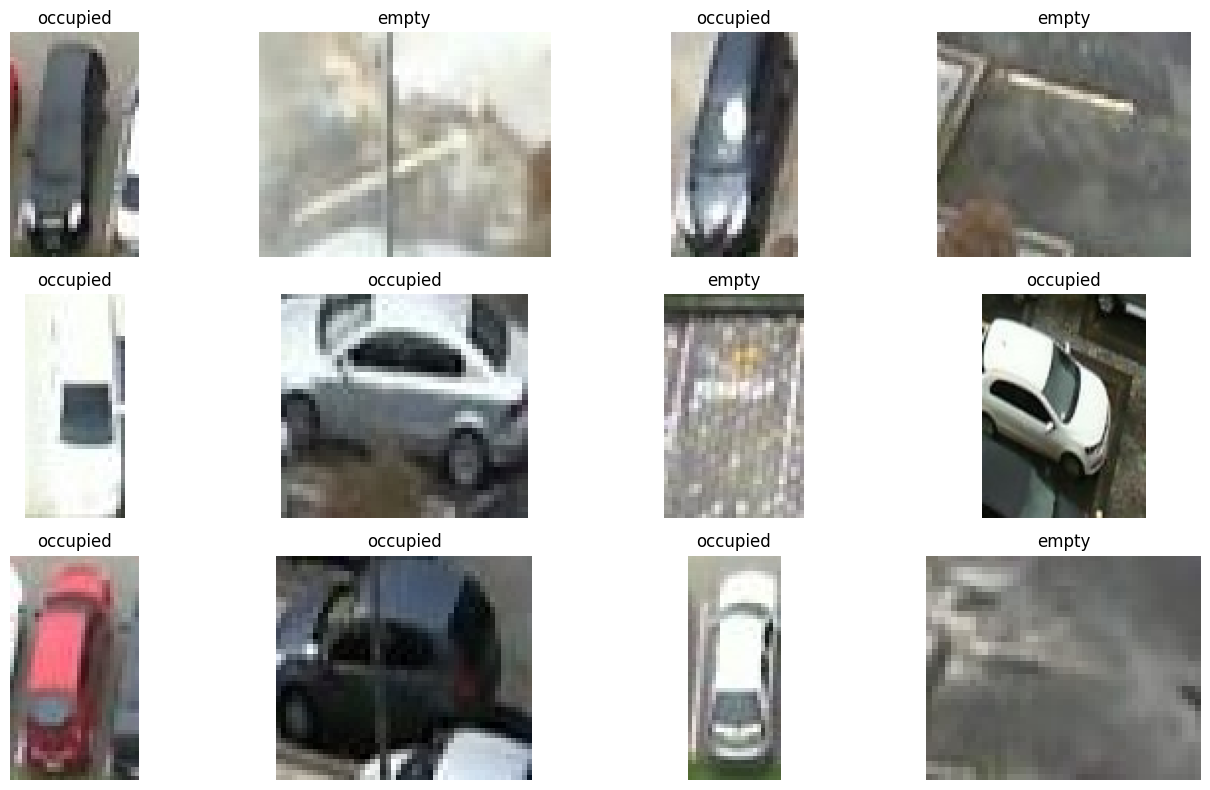

In [8]:
# ============================================================
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "valid"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

split_table = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Total": [len(train_df), len(val_df), len(test_df)],
    "Empty": [(train_df.label == 0).sum(), (val_df.label == 0).sum(), (test_df.label == 0).sum()],
    "Occupied": [(train_df.label == 1).sum(), (val_df.label == 1).sum(), (test_df.label == 1).sum()],
})
display(split_table)
split_table.to_csv(RESULTS_DIR / "split_table.csv", index=False)

sample = df.sample(min(12, len(df)), random_state=SEED)
plt.figure(figsize=(14, 8))
for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(row["class_name"])
    plt.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_crops.png", dpi=150)
plt.show()

## 4. Data loaders

In [9]:
# ============================================================
# 4. Data loaders

## Code

In [10]:
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.25, contrast=0.25)], p=0.6),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ParkingDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), torch.tensor(row["label"], dtype=torch.float32)

def make_loader(dataframe, transform, shuffle=False):
    return DataLoader(ParkingDataset(dataframe, transform), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=True)

train_loader = make_loader(train_df, train_tfms, True)
val_loader = make_loader(val_df, eval_tfms, False)
test_loader = make_loader(test_df, eval_tfms, False)

## 5. Models

In [11]:
# ============================================================
# 5. Models

## Code

In [12]:
# ============================================================
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.35), nn.Linear(256, 1))
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

def build_model(name):
    if name == "CustomCNN":
        return CustomCNN()
    if name == "EfficientNetV2":
        return timm.create_model("tf_efficientnetv2_b0", pretrained=True, num_classes=1)
    if name == "ConvNeXtTiny":
        return timm.create_model("convnext_tiny", pretrained=True, num_classes=1)
    raise ValueError(name)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Metrics and train

In [13]:
# ============================================================
# 6. Metrics and train

## Code

In [14]:
# ============================================================
def evaluate_model(model, loader):
    model.eval()
    y_true, y_prob = [], []
    start = time.time()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x).view(-1)
            probs = torch.sigmoid(logits).cpu().numpy()
            y_prob.extend(probs.tolist())
            y_true.extend(y.numpy().tolist())

    elapsed = time.time() - start
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier_score": brier_score_loss(y_true, y_prob),
        "false_occupancy_rate": fp / (fp + tn + 1e-9),
        "false_vacancy_rate": fn / (fn + tp + 1e-9),
        "inference_ms_per_image": elapsed / max(1, len(y_true)) * 1000,
        "cm": cm,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

def train_one_model(model_name, epochs):
    print(f"\nTraining {model_name}")
    model = build_model(model_name).to(DEVICE)
    print("Parameters:", count_params(model))

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    best_f1 = -1
    best_path = MODEL_DIR / f"{model_name}_best.pth"
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = model(x).view(-1)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        vm = evaluate_model(model, val_loader)
        row = {"epoch": epoch, "train_loss": float(np.mean(losses)),
               "val_accuracy": vm["accuracy"], "val_f1": vm["f1"], "val_roc_auc": vm["roc_auc"]}
        history.append(row)
        print(row)

        if vm["f1"] > best_f1:
            best_f1 = vm["f1"]
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, pd.DataFrame(history), best_path

models_plan = [
    ("CustomCNN", EPOCHS_CUSTOM),
    ("EfficientNetV2", EPOCHS_TRANSFER),
    ("ConvNeXtTiny", EPOCHS_TRANSFER),
]

trained_models, histories, summary_rows = {}, {}, []

for model_name, epochs in models_plan:
    model, history, best_path = train_one_model(model_name, epochs)
    trained_models[model_name] = model
    histories[model_name] = history
    history.to_csv(RESULTS_DIR / f"{model_name}_training_history.csv", index=False)

    tm = evaluate_model(model, test_loader)
    summary_rows.append({
        "model": model_name,
        "accuracy": tm["accuracy"],
        "precision": tm["precision"],
        "recall": tm["recall"],
        "f1": tm["f1"],
        "balanced_accuracy": tm["balanced_accuracy"],
        "roc_auc": tm["roc_auc"],
        "pr_auc": tm["pr_auc"],
        "brier_score": tm["brier_score"],
        "false_occupancy_rate": tm["false_occupancy_rate"],
        "false_vacancy_rate": tm["false_vacancy_rate"],
        "inference_ms_per_image": tm["inference_ms_per_image"],
        "parameters": count_params(model),
        "model_size_mb": os.path.getsize(best_path) / (1024 * 1024),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("f1", ascending=False)
display(summary_df)
summary_df.to_csv(RESULTS_DIR / "model_comparison_results.csv", index=False)

best_model_name = summary_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)


Training CustomCNN
Parameters: 389633
{'epoch': 1, 'train_loss': 0.459576022811234, 'val_accuracy': 0.689, 'val_f1': 0.5802968960863698, 'val_roc_auc': np.float64(0.9365039999999999)}
{'epoch': 2, 'train_loss': 0.3571646739728749, 'val_accuracy': 0.918, 'val_f1': 0.9200779727095516, 'val_roc_auc': np.float64(0.945184)}

Training EfficientNetV2


model.safetensors:   0%|          | 0.00/28.8M [00:00<?, ?B/s]

Parameters: 5859985
{'epoch': 1, 'train_loss': 0.6991889979690313, 'val_accuracy': 0.901, 'val_f1': 0.8950159066808059, 'val_roc_auc': np.float64(0.974572)}
{'epoch': 2, 'train_loss': 0.2068256725615356, 'val_accuracy': 0.937, 'val_f1': 0.9360406091370559, 'val_roc_auc': np.float64(0.98439)}

Training ConvNeXtTiny


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Parameters: 27820897
{'epoch': 1, 'train_loss': 0.4771149653242901, 'val_accuracy': 0.82, 'val_f1': 0.784688995215311, 'val_roc_auc': np.float64(0.985108)}
{'epoch': 2, 'train_loss': 0.15638091001892462, 'val_accuracy': 0.98, 'val_f1': 0.9803149606299213, 'val_roc_auc': np.float64(0.9890519999999999)}


,model,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc,brier_score,false_occupancy_rate,false_vacancy_rate,inference_ms_per_image,parameters,model_size_mb
2,ConvNeXtTiny,0.966,0.939623,0.996,0.966990,0.966,0.977736,0.969686,0.031314,0.064,0.004,4.038319,27820897,106.197062
1,EfficientNetV2,0.931,0.930140,0.932,0.931069,0.931,0.972924,0.966370,0.057770,0.070,0.068,1.471858,5859985,22.731490
0,CustomCNN,0.907,0.883239,0.938,0.909796,0.907,0.933208,0.871906,0.086300,0.124,0.062,1.430808,389633,1.500310


Best model: ConvNeXtTiny


## 7. Figures

In [15]:
# ============================================================
# 7. Figures

## Code

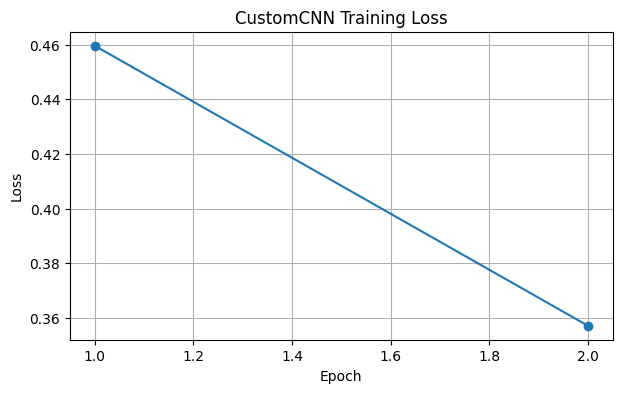

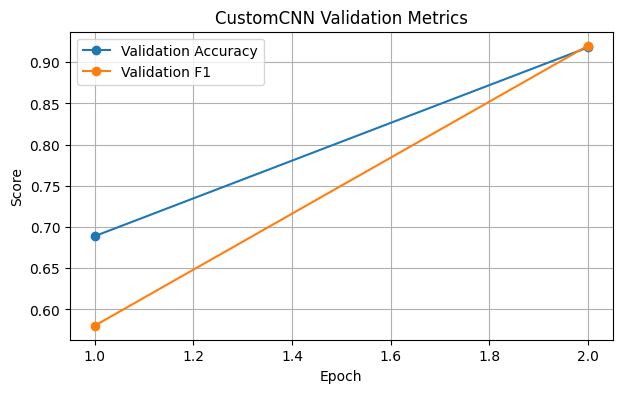

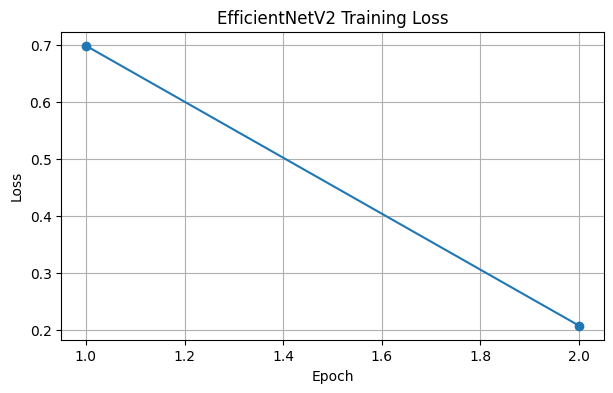

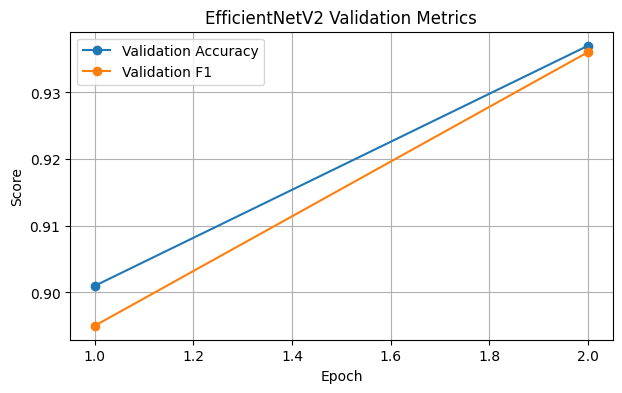

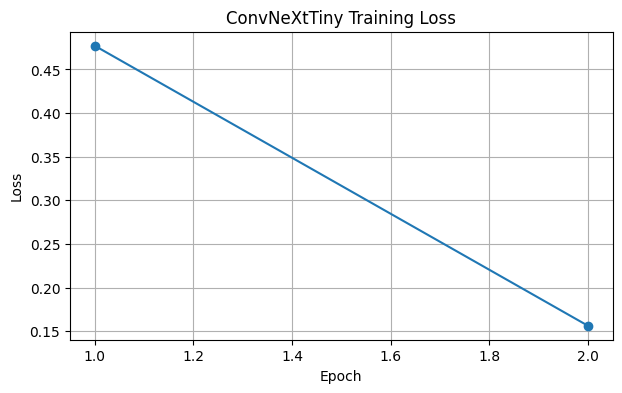

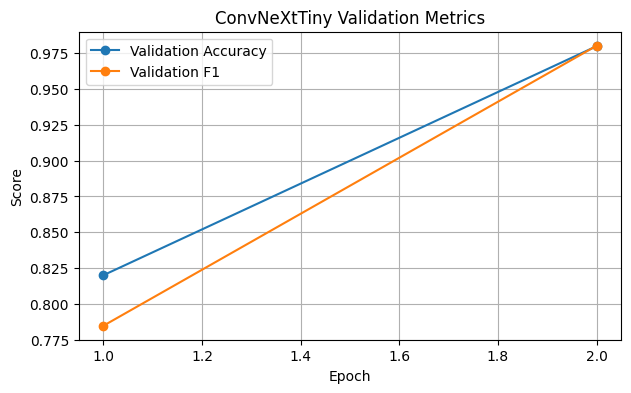

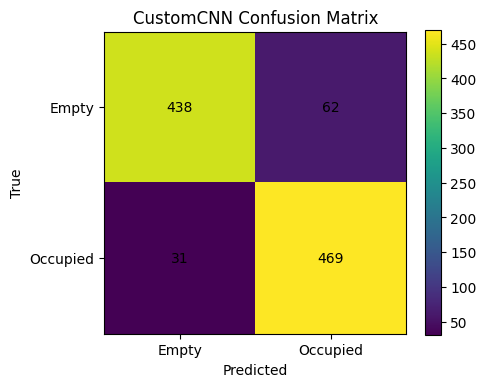

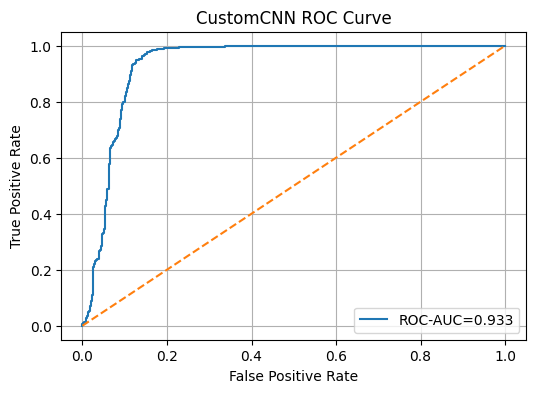

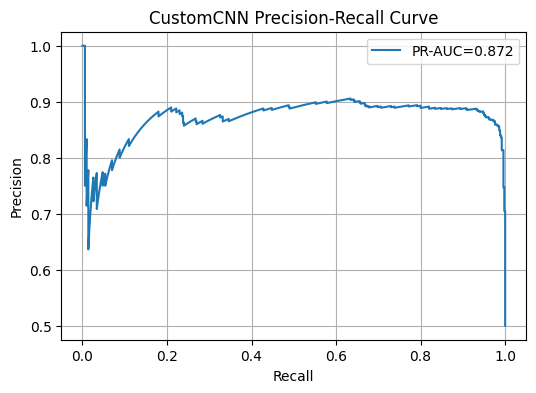

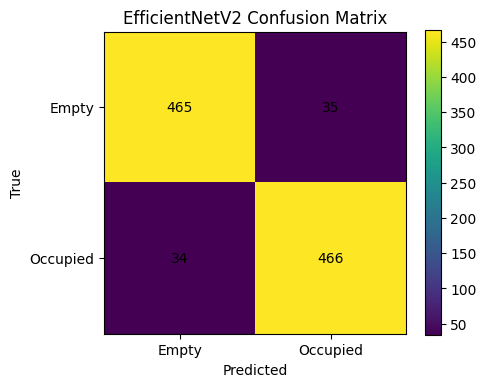

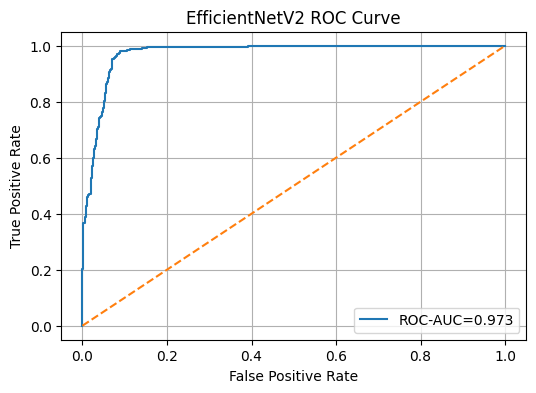

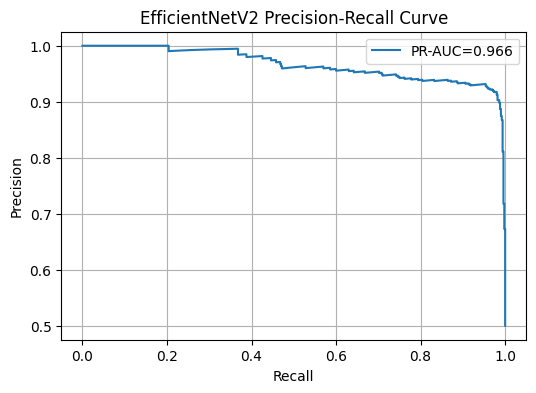

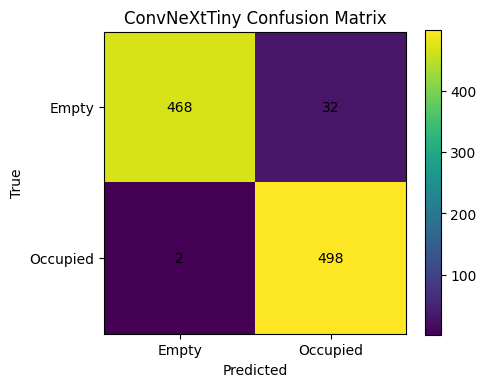

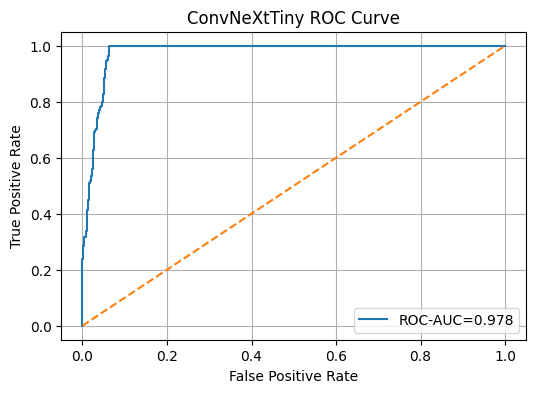

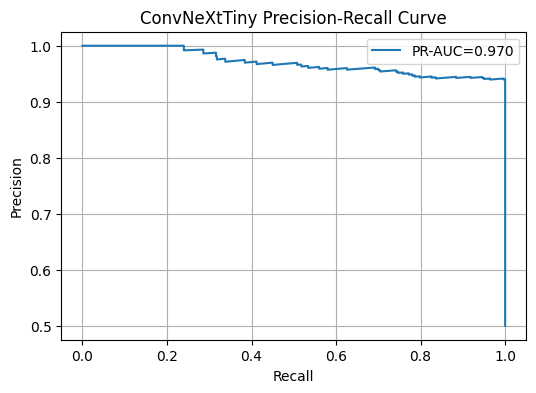

In [16]:
# ============================================================
for name, hist in histories.items():
    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o")
    plt.title(f"{name} Training Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)
    plt.savefig(RESULTS_DIR / f"{name}_training_loss.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.plot(hist["epoch"], hist["val_f1"], marker="o", label="Validation F1")
    plt.title(f"{name} Validation Metrics")
    plt.xlabel("Epoch"); plt.ylabel("Score"); plt.legend(); plt.grid(True)
    plt.savefig(RESULTS_DIR / f"{name}_validation_metrics.png", dpi=150)
    plt.show()

for name, model in trained_models.items():
    m = evaluate_model(model, test_loader)
    cm = m["cm"]

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.xticks([0, 1], ["Empty", "Occupied"])
    plt.yticks([0, 1], ["Empty", "Occupied"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.colorbar(); plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{name}_confusion_matrix.png", dpi=150)
    plt.show()

    fpr, tpr, _ = roc_curve(m["y_true"], m["y_prob"])
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC-AUC={m['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.title(f"{name} ROC Curve")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(); plt.grid(True)
    plt.savefig(RESULTS_DIR / f"{name}_roc_curve.png", dpi=150)
    plt.show()

    precision, recall, _ = precision_recall_curve(m["y_true"], m["y_prob"])
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"PR-AUC={m['pr_auc']:.3f}")
    plt.title(f"{name} Precision-Recall Curve")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(); plt.grid(True)
    plt.savefig(RESULTS_DIR / f"{name}_pr_curve.png", dpi=150)
    plt.show()

## 8. Robustness

In [17]:
# ============================================================
# 8. Robustness

## Code

In [18]:
# ============================================================
def corrupt_image(img, mode):
    img = img.convert("RGB")
    if mode == "low_contrast":
        return ImageEnhance.Contrast(img).enhance(0.45)
    if mode == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=2))
    arr = np.array(img).astype(np.float32)
    h, w = arr.shape[:2]
    if mode == "shadow":
        arr[:h//2] *= 0.55
    if mode == "occlusion":
        arr[h//3:h//3+h//4, w//3:w//3+w//4] = 0
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

class RobustDataset(Dataset):
    def __init__(self, dataframe, mode):
        self.df = dataframe.reset_index(drop=True)
        self.mode = mode
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = corrupt_image(Image.open(row["path"]).convert("RGB"), self.mode)
        return eval_tfms(img), torch.tensor(row["label"], dtype=torch.float32)

robust_rows = []
for condition in ["low_contrast", "blur", "shadow", "occlusion"]:
    robust_loader = DataLoader(RobustDataset(test_df, condition), batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=NUM_WORKERS)
    for name, model in trained_models.items():
        m = evaluate_model(model, robust_loader)
        robust_rows.append({"condition": condition, "model": name, "accuracy": m["accuracy"],
                            "f1": m["f1"], "balanced_accuracy": m["balanced_accuracy"],
                            "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"]})
robust_df = pd.DataFrame(robust_rows)
display(robust_df)
robust_df.to_csv(RESULTS_DIR / "robustness_results.csv", index=False)

,condition,model,accuracy,f1,balanced_accuracy,roc_auc,pr_auc
0,low_contrast,CustomCNN,0.612,0.424332,0.612,0.892204,0.822705
1,low_contrast,EfficientNetV2,0.854,0.838496,0.854,0.966148,0.950248
2,low_contrast,ConvNeXtTiny,0.941,0.941059,0.941,0.969772,0.955281
3,blur,CustomCNN,0.760,0.713604,0.760,0.915728,0.844052
4,blur,EfficientNetV2,0.582,0.289116,0.582,0.818092,0.829866
5,blur,ConvNeXtTiny,0.854,0.837054,0.854,0.971808,0.964720
6,shadow,CustomCNN,0.837,0.855368,0.837,0.900224,0.835154
7,shadow,EfficientNetV2,0.897,0.891920,0.897,0.972732,0.967724
8,shadow,ConvNeXtTiny,0.964,0.964912,0.964,0.975376,0.964661
9,occlusion,CustomCNN,0.901,0.906692,0.901,0.929540,0.866139


## 9. Grad-CAM and calibration

In [19]:
# ============================================================
# 9. Grad-CAM and calibration

## Code

Grad-CAM layer: stages.3.blocks.2.conv_dw


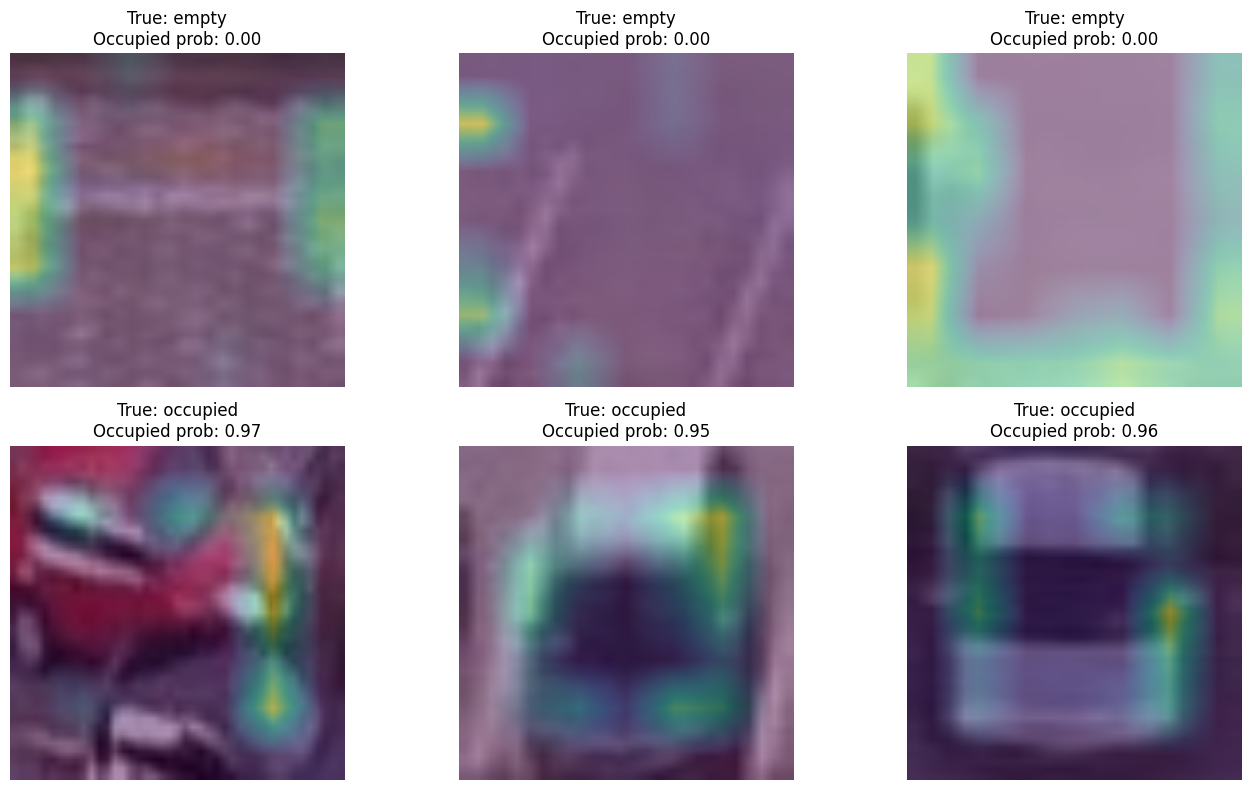

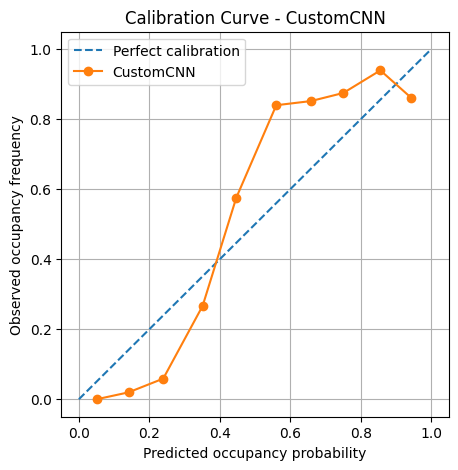

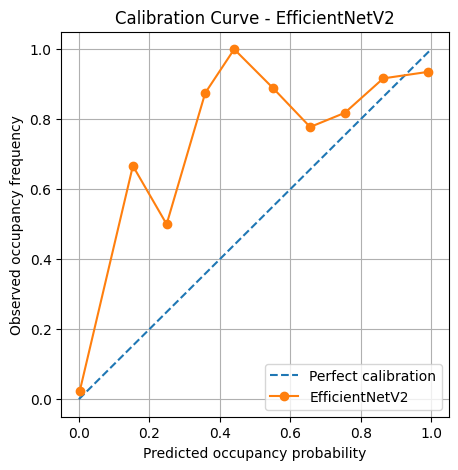

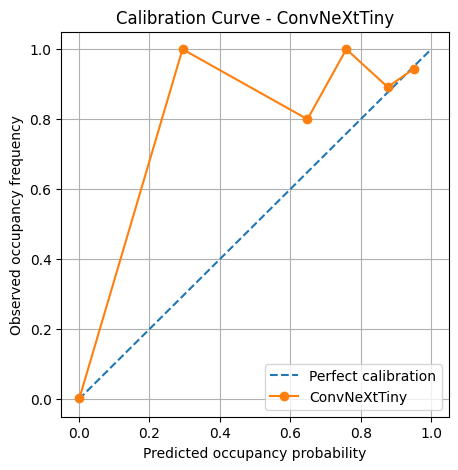

In [20]:
# ============================================================
def find_last_conv_layer(model):
    last_name, last_layer = None, None
    for name, layer in model.named_modules():
        if isinstance(layer, nn.Conv2d):
            last_name, last_layer = name, layer
    return last_name, last_layer

def denormalize_tensor(t):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    x = t.cpu() * std + mean
    return np.clip(x.permute(1, 2, 0).numpy(), 0, 1)

def make_gradcam(model, image_tensor, target_layer):
    activations, gradients = [], []
    def forward_hook(module, inp, out): activations.append(out)
    def backward_hook(module, grad_in, grad_out): gradients.append(grad_out[0])
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.eval()
    x = image_tensor.unsqueeze(0).to(DEVICE)
    score = model(x).squeeze()
    model.zero_grad()
    score.backward()

    act = activations[0].detach()
    grad = gradients[0].detach()
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * act).sum(dim=1)).squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    h1.remove(); h2.remove()
    return cam

layer_name, gradcam_layer = find_last_conv_layer(best_model)
print("Grad-CAM layer:", layer_name)

if gradcam_layer is not None:
    sample_df = test_df.sample(min(6, len(test_df)), random_state=SEED)
    plt.figure(figsize=(14, 8))
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        tensor = eval_tfms(img)
        cam = cv2.resize(make_gradcam(best_model, tensor, gradcam_layer), (IMG_SIZE, IMG_SIZE))
        prob = torch.sigmoid(best_model(tensor.unsqueeze(0).to(DEVICE)).view(-1)).item()

        plt.subplot(2, 3, i + 1)
        plt.imshow(denormalize_tensor(tensor))
        plt.imshow(cam, alpha=0.45)
        plt.title(f'True: {row["class_name"]}\nOccupied prob: {prob:.2f}')
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{best_model_name}_gradcam_examples.png", dpi=150)
    plt.show()

for name, model in trained_models.items():
    m = evaluate_model(model, test_loader)
    y_true, y_prob = m["y_true"], m["y_prob"]
    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(y_prob, bins) - 1
    xs, ys = [], []
    for b in range(10):
        mask = bin_ids == b
        if mask.sum() > 0:
            xs.append(y_prob[mask].mean())
            ys.append(y_true[mask].mean())

    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
    plt.plot(xs, ys, marker="o", label=name)
    plt.title(f"Calibration Curve - {name}")
    plt.xlabel("Predicted occupancy probability")
    plt.ylabel("Observed occupancy frequency")
    plt.legend(); plt.grid(True)
    plt.savefig(RESULTS_DIR / f"{name}_calibration_curve.png", dpi=150)
    plt.show()

## 11. Extra required project checks: weather, cross-site and uncertainty threshold

This section adds the remaining assignment requirements:

- Weather-specific evaluation: sunny, cloudy and rainy when this information is available in file names or paths.
- Cross-site evaluation: held-out parking-site test when site information is available in file names or paths.
- Deployment uncertainty threshold: predictions close to 0.5 are flagged for manual review.


In [21]:

# ============================================================
# 11. Extra required project checks:
# Weather comparison, cross-site evaluation, uncertainty threshold
# ============================================================

import re

def infer_weather_from_text(text):
    text = str(text).lower()
    if "sunny" in text or "sun" in text:
        return "sunny"
    if "cloudy" in text or "cloud" in text:
        return "cloudy"
    if "rainy" in text or "rain" in text:
        return "rainy"
    return "unknown"

def infer_site_from_text(text):
    text = str(text)
    for site in ["PUCPR", "UFPR04", "UFPR05"]:
        if re.search(site, text, re.IGNORECASE):
            return site.upper()
    return "unknown_site"

# Add metadata columns to the cropped dataset
df["weather"] = df["source_image"].apply(infer_weather_from_text)
df["site"] = df["source_image"].apply(infer_site_from_text)

train_df["weather"] = train_df["source_image"].apply(infer_weather_from_text)
val_df["weather"] = val_df["source_image"].apply(infer_weather_from_text)
test_df["weather"] = test_df["source_image"].apply(infer_weather_from_text)

train_df["site"] = train_df["source_image"].apply(infer_site_from_text)
val_df["site"] = val_df["source_image"].apply(infer_site_from_text)
test_df["site"] = test_df["source_image"].apply(infer_site_from_text)

metadata_summary = pd.DataFrame({
    "Metadata": ["Weather values", "Site values"],
    "Detected values": [str(df["weather"].value_counts().to_dict()), str(df["site"].value_counts().to_dict())]
})
display(metadata_summary)
metadata_summary.to_csv(RESULTS_DIR / "metadata_detection_summary.csv", index=False)

# -------------------------
# Weather-specific evaluation
# -------------------------

weather_rows = []

for weather in ["sunny", "cloudy", "rainy", "unknown"]:
    subset = test_df[test_df["weather"] == weather].reset_index(drop=True)
    if len(subset) < 10:
        continue

    subset_loader = make_loader(subset, eval_tfms, shuffle=False)

    for model_name, model in trained_models.items():
        m = evaluate_model(model, subset_loader)
        weather_rows.append({
            "weather": weather,
            "model": model_name,
            "n_samples": len(subset),
            "accuracy": m["accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "balanced_accuracy": m["balanced_accuracy"],
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
            "false_occupancy_rate": m["false_occupancy_rate"],
            "false_vacancy_rate": m["false_vacancy_rate"],
        })

weather_df = pd.DataFrame(weather_rows)
display(weather_df)
weather_df.to_csv(RESULTS_DIR / "weather_specific_performance.csv", index=False)

if len(weather_df) == 0 or set(weather_df["weather"].unique()) == {"unknown"}:
    print(
        "Weather-specific evaluation was saved, but this Roboflow export does not appear to expose "
        "sunny/cloudy/rainy metadata in the image file paths. In the report, mention that the original "
        "PKLot dataset contains weather conditions, but the Kaggle Roboflow export used here does not "
        "preserve explicit weather labels in filenames/paths."
    )

# -------------------------
# Cross-site evaluation
# -------------------------

site_rows = []
known_sites = [s for s in df["site"].unique() if s != "unknown_site"]

if len(known_sites) >= 2:
    held_out_site = df["site"].value_counts().index[0]
    heldout_df = df[df["site"] == held_out_site].reset_index(drop=True)
    heldout_loader = make_loader(heldout_df, eval_tfms, shuffle=False)

    for model_name, model in trained_models.items():
        m = evaluate_model(model, heldout_loader)
        site_rows.append({
            "held_out_site": held_out_site,
            "model": model_name,
            "n_samples": len(heldout_df),
            "accuracy": m["accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "balanced_accuracy": m["balanced_accuracy"],
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
            "false_occupancy_rate": m["false_occupancy_rate"],
            "false_vacancy_rate": m["false_vacancy_rate"],
        })

    cross_site_df = pd.DataFrame(site_rows)
    display(cross_site_df)
    cross_site_df.to_csv(RESULTS_DIR / "cross_site_heldout_performance.csv", index=False)

else:
    cross_site_df = pd.DataFrame([{
        "status": "not_available",
        "reason": (
            "The current Roboflow Kaggle export does not expose site identifiers such as "
            "PUCPR, UFPR04 or UFPR05 in the image paths. Therefore, a true held-out-site "
            "experiment cannot be created from this exported structure without the original "
            "PKLot directory metadata."
        )
    }])
    display(cross_site_df)
    cross_site_df.to_csv(RESULTS_DIR / "cross_site_heldout_performance.csv", index=False)
    print(
        "Cross-site evaluation cannot be performed reliably because site metadata is not visible "
        "in this Roboflow export. This is now documented in the saved CSV and can be explained "
        "as a dataset-export limitation in the report."
    )

# -------------------------
# Deployment uncertainty threshold
# -------------------------

def predict_with_uncertainty(model, image_path, lower=0.40, upper=0.60):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        prob_occupied = torch.sigmoid(model(x).view(-1)).item()

    if lower <= prob_occupied <= upper:
        decision = "manual_review"
    elif prob_occupied > upper:
        decision = "occupied"
    else:
        decision = "empty"

    confidence = max(prob_occupied, 1 - prob_occupied)

    return {
        "image_path": image_path,
        "prob_occupied": prob_occupied,
        "confidence": confidence,
        "decision": decision,
    }

deployment_examples = []
for _, row in test_df.sample(min(20, len(test_df)), random_state=SEED).iterrows():
    deployment_examples.append(predict_with_uncertainty(best_model, row["path"]))

deployment_df = pd.DataFrame(deployment_examples)
display(deployment_df.head(20))
deployment_df.to_csv(RESULTS_DIR / "deployment_uncertainty_examples.csv", index=False)

review_rate = (deployment_df["decision"] == "manual_review").mean()
print(f"Manual review rate on sample predictions: {review_rate:.2%}")

# Save updated notes for the report
with open(RESULTS_DIR / "extra_requirements_notes.txt", "w") as f:
    f.write("""
Extra project requirements added:

1. Weather-specific evaluation:
The notebook attempts to infer sunny, cloudy and rainy metadata from image paths. If the export does not preserve
weather labels, results are reported under 'unknown' and this limitation is documented.

2. Cross-site evaluation:
The notebook attempts to infer site identifiers such as PUCPR, UFPR04 and UFPR05 from image paths. If site labels are
not preserved by the Roboflow export, a true held-out-site experiment is marked as unavailable and documented as a
dataset-export limitation.

3. Deployment uncertainty threshold:
The final model uses an uncertainty threshold. Predictions with occupied probability between 0.40 and 0.60 are marked
as manual_review instead of forcing an empty/occupied label.
""")


,Metadata,Detected values
0,Weather values,"{'unknown': 2000, 'rainy': 1000}"
1,Site values,{'unknown_site': 3000}


,weather,model,n_samples,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc,false_occupancy_rate,false_vacancy_rate
0,unknown,CustomCNN,1000,0.907,0.883239,0.938,0.909796,0.907,0.933208,0.871906,0.124,0.062
1,unknown,EfficientNetV2,1000,0.931,0.930140,0.932,0.931069,0.931,0.972924,0.966370,0.070,0.068
2,unknown,ConvNeXtTiny,1000,0.966,0.939623,0.996,0.966990,0.966,0.977736,0.969686,0.064,0.004


Weather-specific evaluation was saved, but this Roboflow export does not appear to expose sunny/cloudy/rainy metadata in the image file paths. In the report, mention that the original PKLot dataset contains weather conditions, but the Kaggle Roboflow export used here does not preserve explicit weather labels in filenames/paths.


,status,reason
0,not_available,The current Roboflow Kaggle export does not ex...


Cross-site evaluation cannot be performed reliably because site metadata is not visible in this Roboflow export. This is now documented in the saved CSV and can be explained as a dataset-export limitation in the report.


,image_path,prob_occupied,confidence,decision
0,/kaggle/working/pklot_fast_crops/test/empty/te...,0.000043,0.999957,empty
1,/kaggle/working/pklot_fast_crops/test/empty/te...,0.000077,0.999923,empty
2,/kaggle/working/pklot_fast_crops/test/empty/te...,0.000551,0.999449,empty
3,/kaggle/working/pklot_fast_crops/test/occupied...,0.971422,0.971422,occupied
4,/kaggle/working/pklot_fast_crops/test/occupied...,0.945541,0.945541,occupied
5,/kaggle/working/pklot_fast_crops/test/occupied...,0.963447,0.963447,occupied
6,/kaggle/working/pklot_fast_crops/test/occupied...,0.626406,0.626406,occupied
7,/kaggle/working/pklot_fast_crops/test/occupied...,0.945837,0.945837,occupied
8,/kaggle/working/pklot_fast_crops/test/occupied...,0.919571,0.919571,occupied
9,/kaggle/working/pklot_fast_crops/test/occupied...,0.960173,0.960173,occupied


Manual review rate on sample predictions: 0.00%


## 10. Save

In [22]:
# ============================================================
# 10. Save

## Code

In [23]:
# ============================================================
best_model_path = MODEL_DIR / f"{best_model_name}_best.pth"
shutil.copy(best_model_path, RESULTS_DIR / "best_model.pth")

with open(RESULTS_DIR / "best_model_info.txt", "w") as f:
    f.write(f"Best model: {best_model_name}\n\n")
    f.write(summary_df.to_string(index=False))

with open(RESULTS_DIR / "methodology_notes.txt", "w") as f:
    f.write("""
Fast optimized PKLot Roboflow COCO pipeline.
The dataset contains 12,416 640x640 images and 497,856 training annotations.
To avoid very slow preprocessing, this notebook samples annotations before cropping.
Classes: category 1 space-empty -> class 0; category 2 space-occupied -> class 1; category 0 spaces ignored.
Models: Custom CNN, EfficientNetV2-B0, ConvNeXtTiny.
Metrics: accuracy, precision, recall, F1, balanced accuracy, ROC-AUC, PR-AUC, false occupancy,
false vacancy, calibration, confusion matrix, inference time, model size, parameters.
Explainability: Grad-CAM. Robustness: low contrast, blur, shadow, occlusion.
""")

shutil.make_archive(str(WORK_DIR / "pklot_final_results"), "zip", RESULTS_DIR)

print("\nDONE")
print("Final ZIP:", WORK_DIR / "pklot_final_results.zip")


DONE
Final ZIP: /kaggle/working/pklot_final_results.zip
